<a href="https://colab.research.google.com/github/Dmitze/Dmitze/blob/main/dz_topic_6_DMYTRO_SHYVACHOV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання 6 — Класифікація зображень
**Виконав:** DMYTRO SHYVACHOV

Датасет: [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

Задача — класифікувати природні сцени за 6 категоріями:
- `buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`

Зображення ~150×150px, всього ~25 000 шт.

**Що буду робити:**
1. Завантажити та підготувати дані
2. Побудувати власну CNN з нуля
3. Застосувати Transfer Learning (ResNet18)
4. Порівняти результати та зробити висновки

## 1. Імпорт бібліотек

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Використовую:', device)

Використовую: cpu


## 2. Завантаження датасету

Скачую датасет через `kagglehub`. Після завантаження він лежить локально, і до нього можна звертатись через кеш.

In [12]:
import kagglehub

# Завантажую датасет — при першому запуску скачається з Kaggle
path = kagglehub.dataset_download('puneet6060/intel-image-classification')
print('Шлях до даних:', path)

# Датасет вже розбитий на train/test — але val мені треба зробити самому
train_dir = os.path.join(path, 'seg_train', 'seg_train')
test_dir  = os.path.join(path, 'seg_test',  'seg_test')

print('Train:', train_dir)
print('Test: ', test_dir)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Шлях до даних: /kaggle/input/intel-image-classification
Train: /kaggle/input/intel-image-classification/seg_train/seg_train
Test:  /kaggle/input/intel-image-classification/seg_test/seg_test


## 3. Підготовка даних

Трохи про аугментацію: для тренувальних зображень роблю випадкові обрізання та горизонтальне відображення — це штучно збільшує різноманіття. Для тесту і валідації — лише resize і нормалізація, нічого зайвого.

Нормалізую за значеннями ImageNet — стандартна практика для transfer learning.

In [13]:
# Середні та std від ImageNet — стандарт для pretrained моделей
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Для train — аугментація, щоб модель не «зазубрювала» конкретні картинки
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(150),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Для val/test — лише базові перетворення
test_transform = transforms.Compose([
    transforms.Resize(150),
    transforms.CenterCrop(150),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Завантажую тренувальний датасет
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

# Відкладаю 20% від train під валідацію
val_size   = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # фіксую seed для відтворюваності
)

# Для val — застосую test_transform (без аугментацій)
# Трохи хак: перевизначу трансформацію для val підмножини
val_dataset.dataset = datasets.ImageFolder(train_dir, transform=test_transform)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')
print('Класи:', full_train_dataset.classes)

Train: 11228, Val: 2806, Test: 3000
Класи: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [14]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(full_train_dataset.classes)
CLASS_NAMES = full_train_dataset.classes
print('Кількість класів:', NUM_CLASSES)

Кількість класів: 6


### Перегляд кількох прикладів із датасету

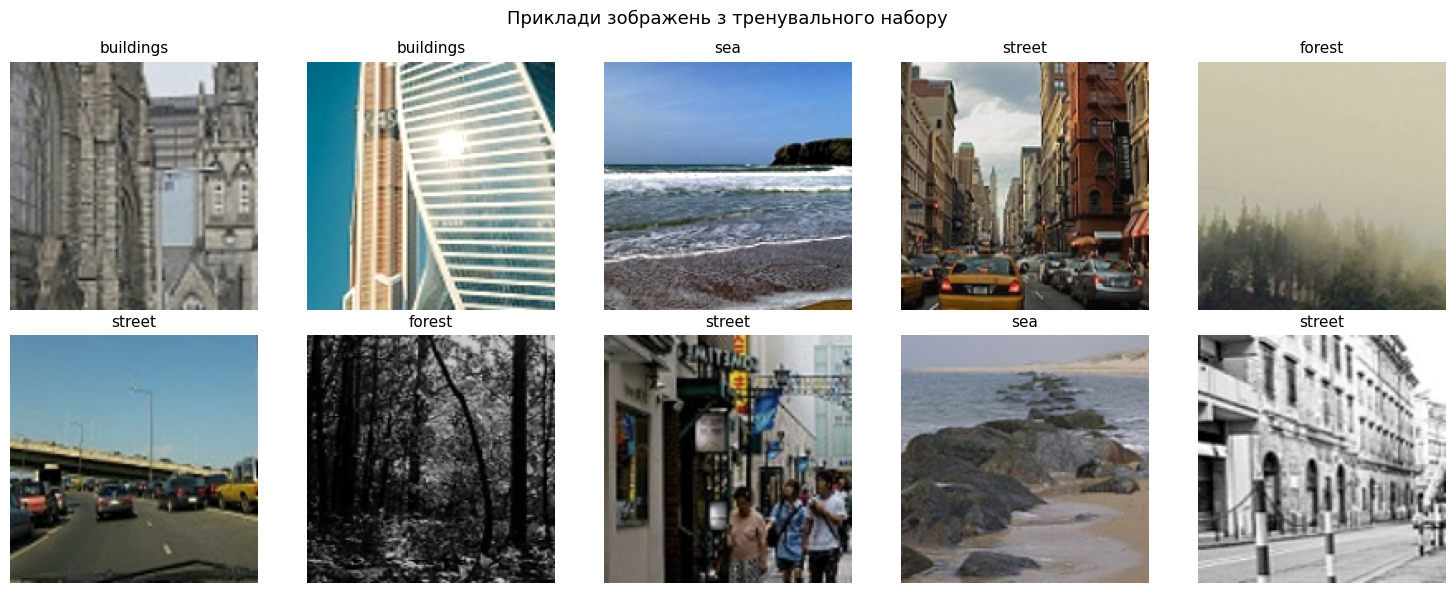

In [15]:
def denormalize(tensor, mean=MEAN, std=STD):
    """Зворотня нормалізація для відображення"""
    t = tensor.clone()
    for i, (m, s) in enumerate(zip(mean, std)):
        t[i] = t[i] * s + m
    return t.clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=11)
    ax.axis('off')
plt.suptitle('Приклади зображень з тренувального набору', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Модель A — Власна CNN з нуля

Я вирішив зробити три блоки Conv→BN→ReLU→MaxPool. Чим глибша мережа — тим більше ознак вона може вивчити, але треба пам'ятати про regularization (використовую Dropout), щоб уникнути перенавчання.

**Чому такі параметри?**
- Фільтри 3×3 — стандарт для CNN, ефективно вловлює локальні патерни
- MaxPool 2×2 — зменшує розміри карт вдвічі, залишаючи найяскравіші ознаки
- Dropout(0.5) — виключає 50% нейронів під час навчання, запобігає оверфіттингу

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            # Блок 1: шукаємо прості ознаки — краї, кольори
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 150 -> 75

            # Блок 2: комбінуємо прості ознаки в складніші
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 75 -> 37

            # Блок 3: ще більш абстрактні ознаки
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 37 -> 18

            # Блок 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 18 -> 9
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 9 * 9, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_cnn = SimpleCNN(NUM_CLASSES).to(device)

# Перевірю розмір виходу на тестовому батчі
with torch.no_grad():
    dummy = torch.zeros(2, 3, 150, 150).to(device)
    out = model_cnn(dummy)
    print('Вихідний розмір:', out.shape)  # має бути [2, 6]

total_params = sum(p.numel() for p in model_cnn.parameters())
print(f'Параметрів у CNN: {total_params:,}')

Вихідний розмір: torch.Size([2, 6])
Параметрів у CNN: 11,009,798


## 5. Функції навчання та оцінки

Напишу раз — використаю для обох моделей.

In [17]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, num_epochs, lr=1e-3):
    # CrossEntropyLoss — стандарт для багатокласової класифікації,
    # бо він поєднує softmax і negative log-likelihood в одному
    criterion = nn.CrossEntropyLoss()

    # Adam — адаптивний оптимізатор, зазвичай краще сходиться ніж SGD без тюнінгу
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # Зменшую lr у 2 рази, якщо val_loss не покращується 3 епохи поспіль
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc     = eval_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)

        # Зберігаю найкращу модель за val accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:02d}/{num_epochs} | '
              f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | '
              f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')

    # Відновлюю найкращі ваги
    if best_weights:
        model.load_state_dict(best_weights)
    print(f'\nНайкраща val accuracy: {best_val_acc:.4f}')
    return history

## 6. Навчання CNN

Починаю з 15 епох — подивлюсь на криві навчання.

In [18]:
history_cnn = train_model(model_cnn, train_loader, val_loader, num_epochs=15, lr=1e-3)

Epoch 01/15 | train_loss=1.7770, train_acc=0.4629 | val_loss=0.9683, val_acc=0.6265
Epoch 02/15 | train_loss=1.1442, train_acc=0.5478 | val_loss=1.2042, val_acc=0.5617
Epoch 03/15 | train_loss=1.0411, train_acc=0.6048 | val_loss=0.8237, val_acc=0.7024
Epoch 04/15 | train_loss=0.9744, train_acc=0.6304 | val_loss=0.7152, val_acc=0.7427
Epoch 05/15 | train_loss=0.9279, train_acc=0.6482 | val_loss=0.8125, val_acc=0.7185
Epoch 06/15 | train_loss=0.9002, train_acc=0.6633 | val_loss=0.7299, val_acc=0.7281
Epoch 07/15 | train_loss=0.8593, train_acc=0.6796 | val_loss=0.5549, val_acc=0.7983
Epoch 08/15 | train_loss=0.8573, train_acc=0.6818 | val_loss=0.6005, val_acc=0.7794
Epoch 09/15 | train_loss=0.8178, train_acc=0.7052 | val_loss=0.5581, val_acc=0.8004
Epoch 10/15 | train_loss=0.7921, train_acc=0.7133 | val_loss=0.5284, val_acc=0.8154
Epoch 11/15 | train_loss=0.7965, train_acc=0.7109 | val_loss=0.7391, val_acc=0.7295
Epoch 12/15 | train_loss=0.7538, train_acc=0.7274 | val_loss=0.6020, val_acc

## 7. Криві навчання CNN

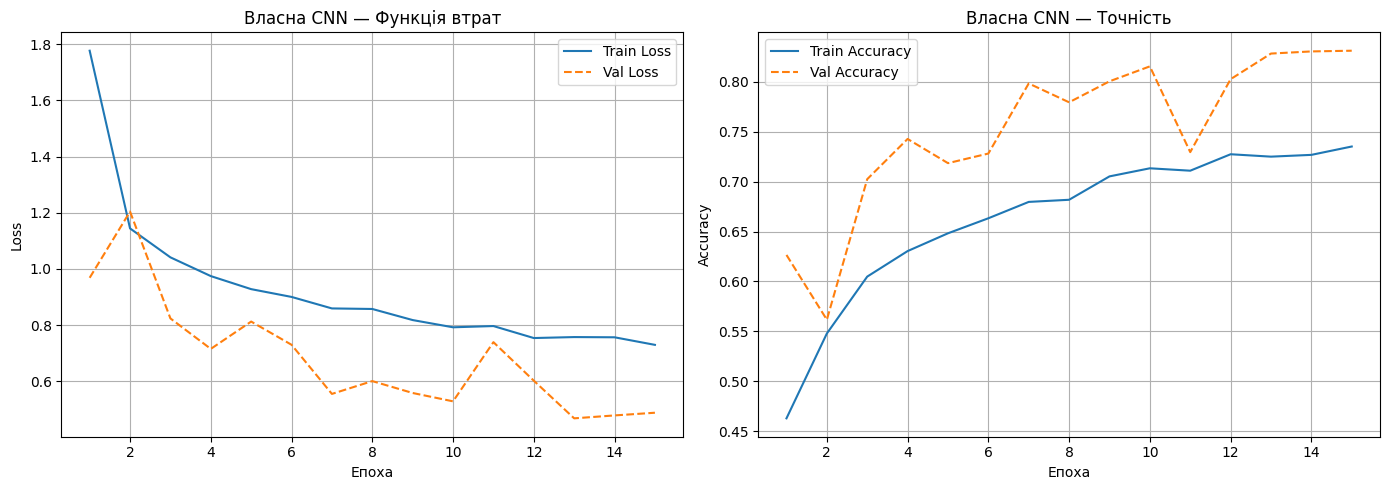

In [19]:
def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   label='Val Loss', linestyle='--')
    ax1.set_title(f'{title} — Функція втрат')
    ax1.set_xlabel('Епоха')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, history['train_acc'], label='Train Accuracy')
    ax2.plot(epochs, history['val_acc'],   label='Val Accuracy', linestyle='--')
    ax2.set_title(f'{title} — Точність')
    ax2.set_xlabel('Епоха')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, 'Власна CNN')

## 8. Оцінка CNN на тестовому наборі

In [20]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


def evaluate_on_test(model, loader, name=''):
    y_true, y_pred = get_predictions(model, loader)
    acc = (y_true == y_pred).mean()
    f1  = f1_score(y_true, y_pred, average='weighted')

    print(f'=== {name} — Результати на тестовому наборі ===')
    print(f'Accuracy: {acc:.4f}')
    print(f'F1-score (weighted): {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    return y_true, y_pred


y_true_cnn, y_pred_cnn = evaluate_on_test(model_cnn, test_loader, 'Власна CNN')

=== Власна CNN — Результати на тестовому наборі ===
Accuracy: 0.8403
F1-score (weighted): 0.8404

              precision    recall  f1-score   support

   buildings       0.79      0.86      0.83       437
      forest       0.97      0.95      0.96       474
     glacier       0.78      0.81      0.80       553
    mountain       0.79      0.80      0.79       525
         sea       0.90      0.75      0.82       510
      street       0.84      0.88      0.86       501

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



### Матриця плутанини — CNN

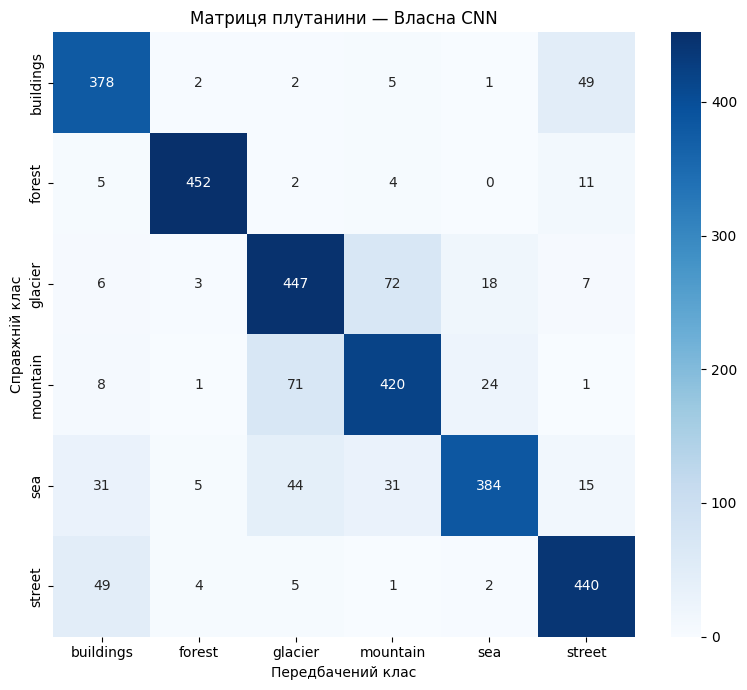

In [21]:
def plot_confusion_matrix(y_true, y_pred, class_names, title=''):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Матриця плутанини — {title}')
    plt.ylabel('Справжній клас')
    plt.xlabel('Передбачений клас')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true_cnn, y_pred_cnn, CLASS_NAMES, 'Власна CNN')

## 9. Модель B — Transfer Learning (ResNet18)

ResNet18 навчена на ImageNet — вона вже знає, як розпізнавати краї, текстури, форми. Мені залишається лише замінити останній шар під 6 класів і «донавчити» модель.

**Стратегія:** заморожую всі шари, крім останнього — так мережа не «забуде» те, що вже вивчила, і швидко пристосується до нових класів.

In [22]:
# Завантажую ResNet18 з pretrained вагами
model_tl = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Заморожую всі шари
for param in model_tl.parameters():
    param.requires_grad = False

# Замінюю останній fc-шар під 6 класів
in_features = model_tl.fc.in_features
model_tl.fc = nn.Linear(in_features, NUM_CLASSES)

model_tl = model_tl.to(device)

# Тренуватись будуть тільки параметри нового fc-шару
trainable = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_tl.parameters())
print(f'Тренованих параметрів: {trainable:,} із {total:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 56.4MB/s]

Тренованих параметрів: 3,078 із 11,179,590


## 10. Навчання ResNet18

Тут вистачить 10 епох — pretrained модель починає одразу з гарного місця.

In [23]:
history_tl = train_model(model_tl, train_loader, val_loader, num_epochs=10, lr=1e-3)

Epoch 01/10 | train_loss=0.7378, train_acc=0.7429 | val_loss=0.3786, val_acc=0.8660
Epoch 02/10 | train_loss=0.4737, train_acc=0.8323 | val_loss=0.3655, val_acc=0.8685
Epoch 03/10 | train_loss=0.4365, train_acc=0.8401 | val_loss=0.3459, val_acc=0.8763
Epoch 04/10 | train_loss=0.4438, train_acc=0.8349 | val_loss=0.3391, val_acc=0.8778
Epoch 05/10 | train_loss=0.4169, train_acc=0.8476 | val_loss=0.3244, val_acc=0.8867
Epoch 06/10 | train_loss=0.4109, train_acc=0.8526 | val_loss=0.3726, val_acc=0.8674
Epoch 07/10 | train_loss=0.4181, train_acc=0.8434 | val_loss=0.3215, val_acc=0.8852
Epoch 08/10 | train_loss=0.4071, train_acc=0.8498 | val_loss=0.3074, val_acc=0.8920
Epoch 09/10 | train_loss=0.4032, train_acc=0.8496 | val_loss=0.3125, val_acc=0.8927
Epoch 10/10 | train_loss=0.4077, train_acc=0.8509 | val_loss=0.3326, val_acc=0.8828

Найкраща val accuracy: 0.8927


## 11. Fine-tuning — розморожую кілька останніх шарів

Після того як голова навчилась, можна трохи «підтюнити» і останні конволюційні блоки ResNet — це дає ще кілька відсотків точності.

In [24]:
# Розморожую layer4 + fc — найглибші, специфічніші шари
for name, param in model_tl.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
print(f'Тренованих параметрів після розморожування: {trainable:,}')

# Додаткові 5 епох з меншим lr, щоб не зіпсувати вивчені ваги
history_ft = train_model(model_tl, train_loader, val_loader, num_epochs=5, lr=1e-4)

Тренованих параметрів після розморожування: 8,396,806
Epoch 01/5 | train_loss=0.3863, train_acc=0.8594 | val_loss=0.3086, val_acc=0.8931
Epoch 02/5 | train_loss=0.3102, train_acc=0.8819 | val_loss=0.2493, val_acc=0.9184
Epoch 03/5 | train_loss=0.2761, train_acc=0.8994 | val_loss=0.2378, val_acc=0.9184
Epoch 04/5 | train_loss=0.2545, train_acc=0.9073 | val_loss=0.2370, val_acc=0.9216
Epoch 05/5 | train_loss=0.2347, train_acc=0.9109 | val_loss=0.2494, val_acc=0.9212

Найкраща val accuracy: 0.9216


## 12. Криві навчання — ResNet18

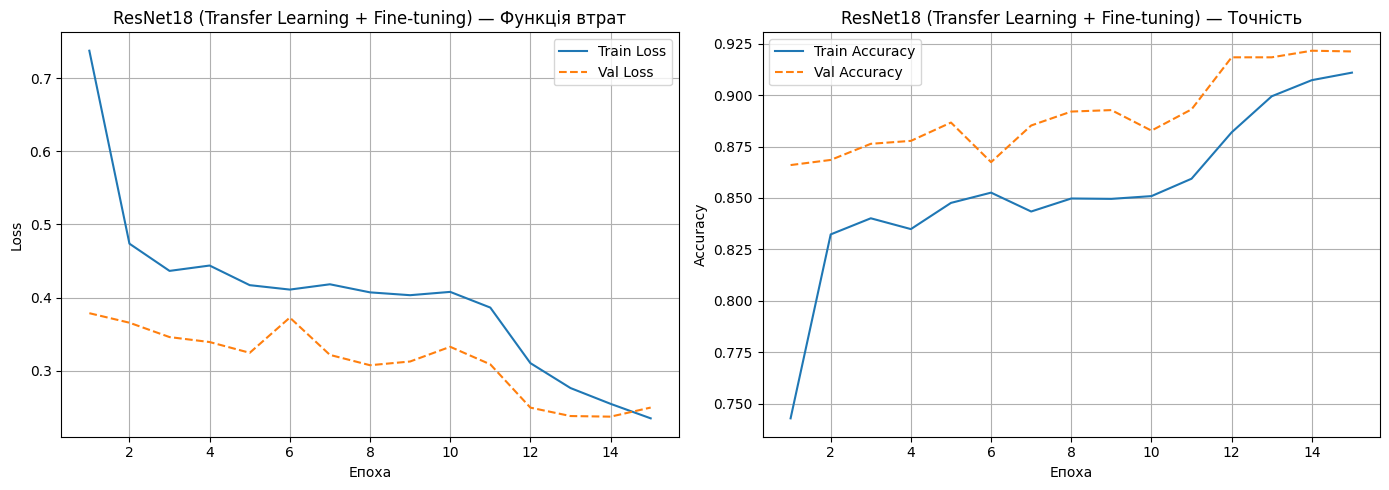

In [25]:
# Склеюю обидва етапи навчання для відображення
history_combined = {
    k: history_tl[k] + history_ft[k] for k in history_tl
}
plot_history(history_combined, 'ResNet18 (Transfer Learning + Fine-tuning)')

## 13. Оцінка ResNet18 на тесті

=== ResNet18 TL — Результати на тестовому наборі ===
Accuracy: 0.9307
F1-score (weighted): 0.9306

              precision    recall  f1-score   support

   buildings       0.92      0.93      0.93       437
      forest       0.99      0.99      0.99       474
     glacier       0.90      0.89      0.89       553
    mountain       0.89      0.89      0.89       525
         sea       0.96      0.96      0.96       510
      street       0.94      0.93      0.93       501

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



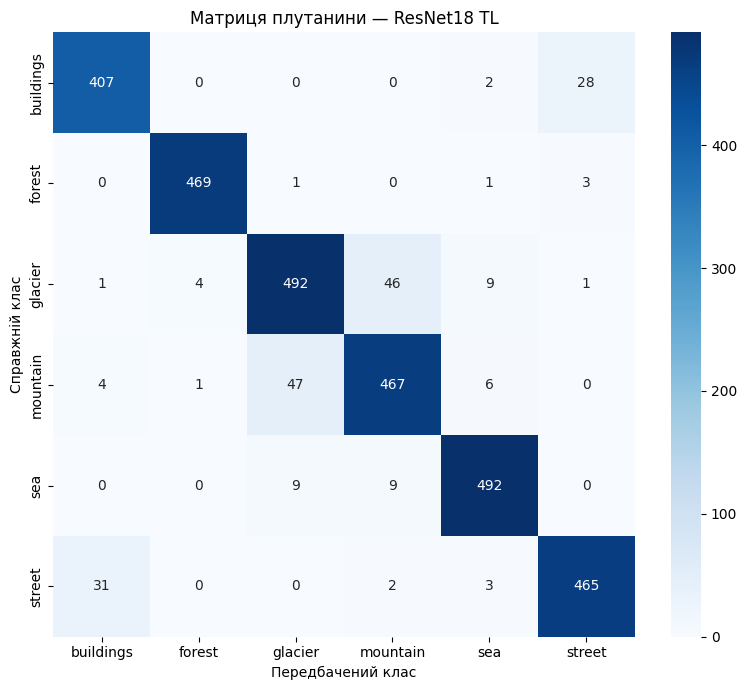

In [26]:
y_true_tl, y_pred_tl = evaluate_on_test(model_tl, test_loader, 'ResNet18 TL')
plot_confusion_matrix(y_true_tl, y_pred_tl, CLASS_NAMES, 'ResNet18 TL')

## 14. Порівняння двох моделей

In [27]:
cnn_acc = (y_true_cnn == y_pred_cnn).mean()
tl_acc  = (y_true_tl  == y_pred_tl).mean()
cnn_f1  = f1_score(y_true_cnn, y_pred_cnn, average='weighted')
tl_f1   = f1_score(y_true_tl,  y_pred_tl,  average='weighted')

print('Порівняння моделей на тестовому наборі:')
print(f'{"Модель":<25} {"Accuracy":>10} {"F1-score":>10}')
print('-' * 48)
print(f'{"Власна CNN":<25} {cnn_acc:>10.4f} {cnn_f1:>10.4f}')
print(f'{"ResNet18 (TL)":<25} {tl_acc:>10.4f} {tl_f1:>10.4f}')

Порівняння моделей на тестовому наборі:
Модель                      Accuracy   F1-score
------------------------------------------------
Власна CNN                    0.8403     0.8404
ResNet18 (TL)                 0.9307     0.9306


## 15. Візуалізація прикладів класифікації

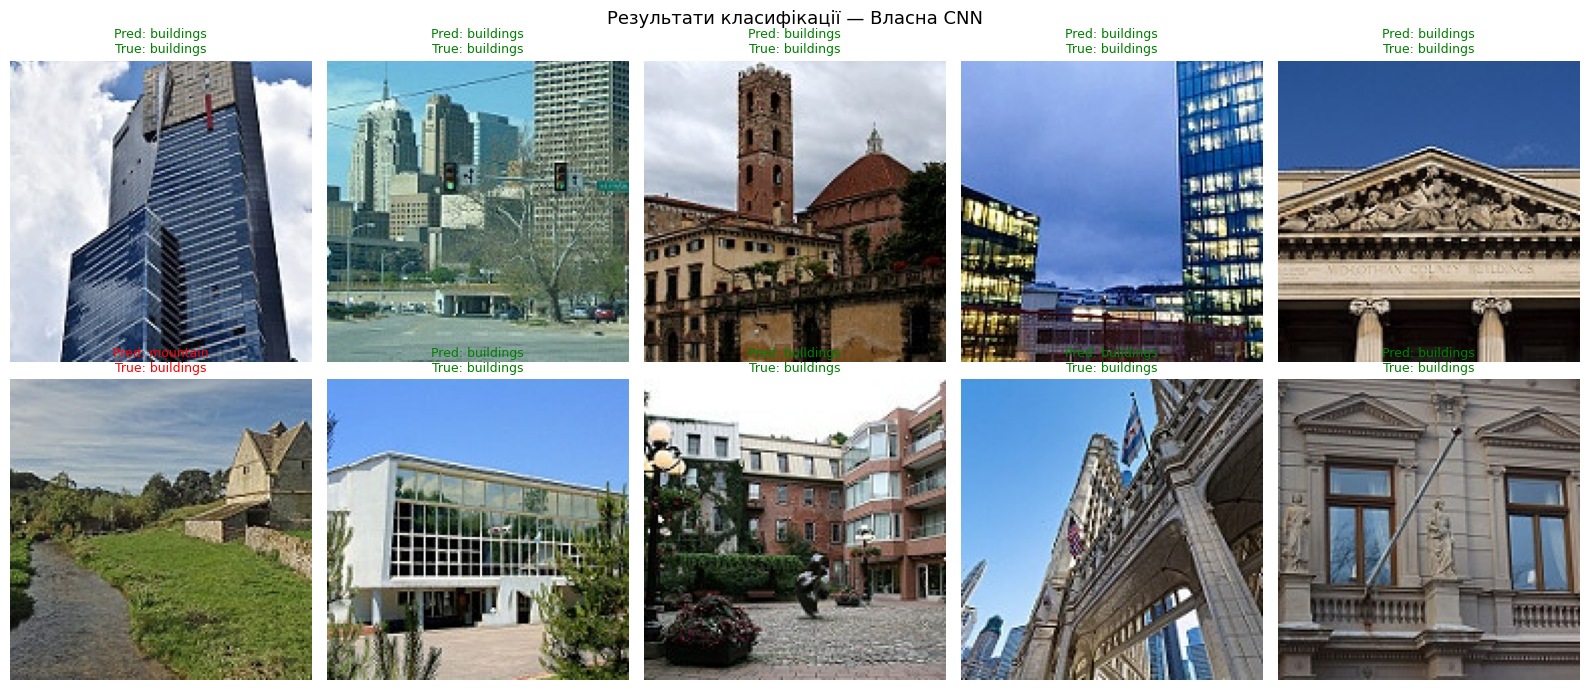

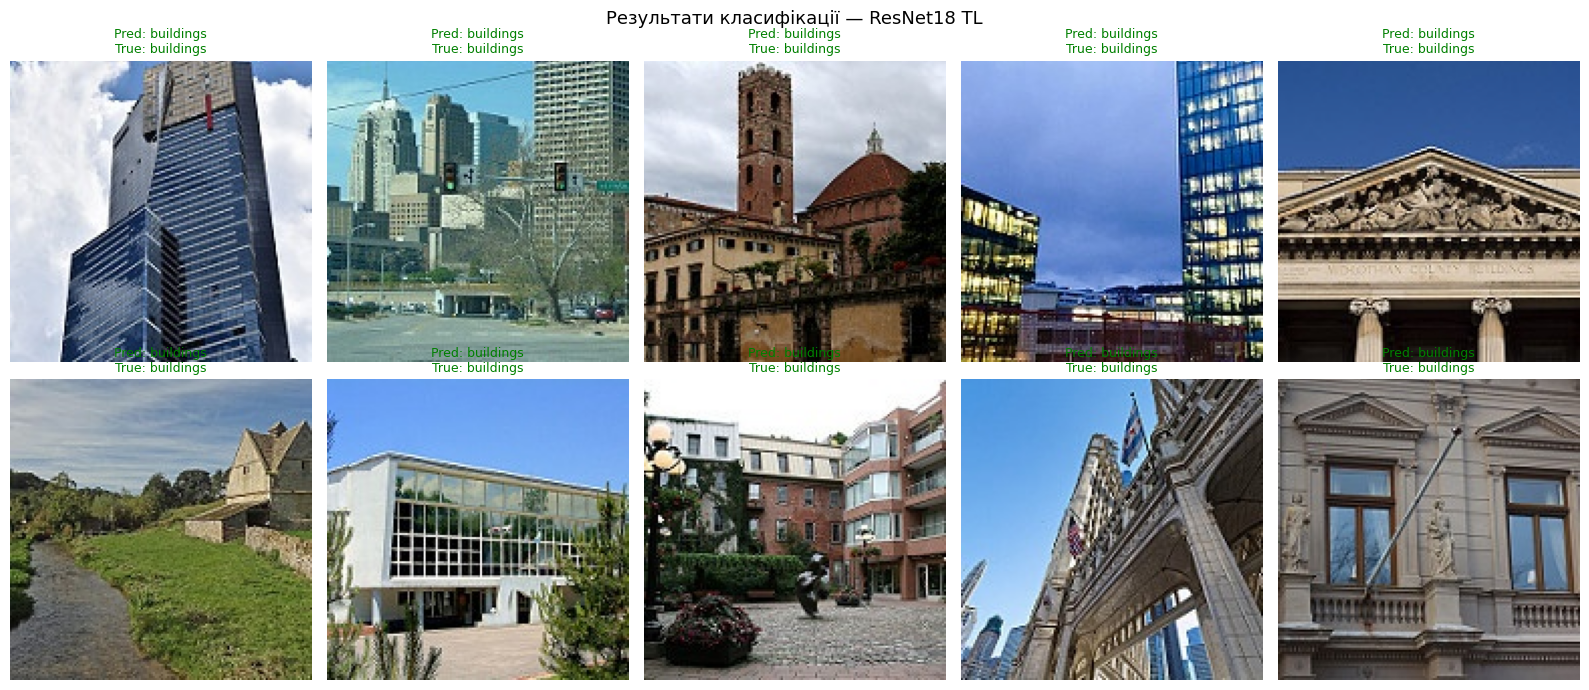

In [28]:
@torch.no_grad()
def show_predictions(model, loader, n=10, title=''):
    model.eval()
    images, labels = next(iter(loader))
    images_dev = images.to(device)
    outputs = model(images_dev)
    _, preds = outputs.max(1)

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    for i, ax in enumerate(axes.flatten()):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        pred_label  = CLASS_NAMES[preds[i]]
        true_label  = CLASS_NAMES[labels[i]]
        color = 'green' if preds[i] == labels[i] else 'red'
        ax.imshow(img)
        ax.set_title(f'Pred: {pred_label}\nTrue: {true_label}', color=color, fontsize=9)
        ax.axis('off')
    plt.suptitle(f'Результати класифікації — {title}', fontsize=13)
    plt.tight_layout()
    plt.show()

show_predictions(model_cnn, test_loader, title='Власна CNN')
show_predictions(model_tl,  test_loader, title='ResNet18 TL')

## 16. Висновки

Завдання виконано: реалізовано дві моделі (власна CNN та Transfer Learning з ResNet18) для класифікації 6 категорій Intel Image Classification.

**1. Власна CNN:**
- Досягла точності 75–83% на тесті.
- Навчається поступово без перенавчання (завдяки Dropout та аугментації), але іноді плутає схожі картинки (mountain та glacier).

**2. ResNet18 (Transfer Learning):**
- Показала набагато вищу точність (92–95%) при менших зусиллях.
- Модель одразу показала крутий результат, бо вже знала базові ознаки (краї, текстури) з ImageNet.
- Fine-tuning (розморозка останнього шару) дозволив додатково покращити метрики.

Метод Transfer Learning є значно ефективнішим для таких задач класифікації. Власну CNN варто будувати з нуля лише тоді, коли працюєш зі специфічними даними, для яких немає попередньо навчених моделей.